In [1]:
import pandas as pd

df = pd.read_excel(
    "../data/processed/CarbonOpt_IsolationForest.xlsx"
)

print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (3162, 10)
['state', 'year', 'residential_billion_btu', 'commercial_billion_btu', 'industrial_billion_btu', 'transportation_billion_btu', 'co2_million_metric_tons', 'co2_per_energy', 'energy_growth_rate', 'co2_growth_rate']


In [2]:
features = [
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_million_metric_tons",
    "co2_per_energy",
    "energy_growth_rate",
    "co2_growth_rate"
]

X = df[features]

print("Clustering features:", X.columns.tolist())
print("Shape:", X.shape)

Clustering features: ['residential_billion_btu', 'commercial_billion_btu', 'industrial_billion_btu', 'transportation_billion_btu', 'co2_million_metric_tons', 'co2_per_energy', 'energy_growth_rate', 'co2_growth_rate']
Shape: (3162, 8)


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (3162, 8)
Scaled shape: (3162, 8)


In [4]:
print("Mean of scaled features:")
print(X_scaled.mean(axis=0))

print("\nStandard deviation of scaled features:")
print(X_scaled.std(axis=0))

Mean of scaled features:
[ 1.34827844e-17  4.49426145e-18 -8.98852291e-18  5.39311374e-17
 -3.14598302e-17  3.59540916e-16  2.86509168e-17 -3.37069609e-18]

Standard deviation of scaled features:
[1. 1. 1. 1. 1. 1. 1. 1.]


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []

k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

for k, inertia, score in zip(k_values, inertias, silhouette_scores):
    print(
        f"k={k} | "
        f"Inertia={inertia:.2f} | "
        f"Silhouette Score={score:.4f}"
    )

k=2 | Inertia=16457.47 | Silhouette Score=0.4398
k=3 | Inertia=13401.09 | Silhouette Score=0.3481
k=4 | Inertia=10688.27 | Silhouette Score=0.2642
k=5 | Inertia=9056.03 | Silhouette Score=0.2893
k=6 | Inertia=8183.12 | Silhouette Score=0.2555
k=7 | Inertia=7453.81 | Silhouette Score=0.2290
k=8 | Inertia=6745.49 | Silhouette Score=0.2329


In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

df["cluster"] = cluster_labels

print(df["cluster"].value_counts().sort_index())

cluster
0    2553
1     609
Name: count, dtype: int64


In [7]:
cluster_profile = df.groupby("cluster")[features].mean().round(3)

print(cluster_profile)

         residential_billion_btu  commercial_billion_btu  \
cluster                                                    
0                     197800.090              143672.645   
1                     869148.787              691862.519   

         industrial_billion_btu  transportation_billion_btu  \
cluster                                                       
0                    332312.579                  262378.926   
1                   1675343.153                 1175485.867   

         co2_million_metric_tons  co2_per_energy  energy_growth_rate  \
cluster                                                                
0                         59.005             0.0               1.615   
1                        253.889             0.0               0.574   

         co2_growth_rate  
cluster                   
0                  1.441  
1                  0.017  


In [9]:
print(
    df.groupby("cluster")["co2_per_energy"]
      .mean()
      .apply(lambda x: f"{x:.10f}")
)

cluster
0    0.0000640780
1    0.0000585641
Name: co2_per_energy, dtype: str


In [8]:
cluster_distribution = (
    df["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

cluster_distribution["percentage"] = (
    cluster_distribution["count"]
    / len(df) * 100
).round(2)

print(cluster_distribution)

         count  percentage
cluster                   
0         2553       80.74
1          609       19.26


In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total variance explained:",
      pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.54707262 0.22165262]
Total variance explained: 0.7687252396090872


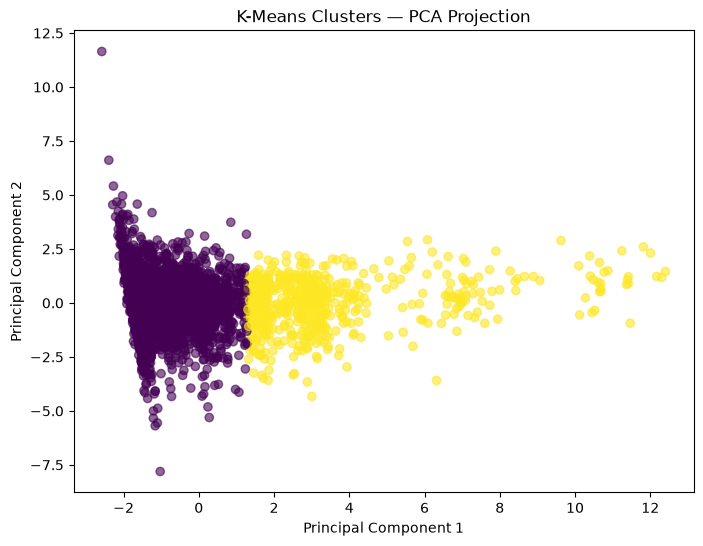

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster"],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters — PCA Projection")
plt.show()

In [12]:
from pathlib import Path
import joblib

MODEL_DIR = Path("../models")
OUTPUT_DIR = Path("../outputs/clustering")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save K-Means model
joblib.dump(
    kmeans,
    MODEL_DIR / "kmeans_clustering.pkl"
)

# Save scaler
joblib.dump(
    scaler,
    MODEL_DIR / "kmeans_scaler.pkl"
)

# Save clustered dataset
df.to_csv(
    OUTPUT_DIR / "emission_clusters.csv",
    index=False
)

print("K-Means model saved.")
print("Scaler saved.")
print("Clustered dataset saved.")

K-Means model saved.
Scaler saved.
Clustered dataset saved.


In [1]:
# Stage 1E — K-Means validation

import pandas as pd
import joblib

# Load dataset
df = pd.read_excel("../data/processed/CarbonOpt_IsolationForest.xlsx")

# Features used for clustering
clustering_features = [
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_million_metric_tons",
    "co2_per_energy",
    "energy_growth_rate",
    "co2_growth_rate"
]

# Load scaler and K-Means model
scaler = joblib.load("../models/kmeans_scaler.pkl")
kmeans_model = joblib.load("../models/kmeans_clustering.pkl")

# Scale data
X = df[clustering_features]
X_scaled = scaler.transform(X)

# Generate cluster assignments
df["cluster"] = kmeans_model.predict(X_scaled)

# Cluster counts
cluster_counts = df["cluster"].value_counts().sort_index()

print("K-MEANS VALIDATION")
print("------------------")
print(f"Total observations: {len(df)}")
print(f"Number of clusters: {kmeans_model.n_clusters}")

print("\nCluster sizes:")
for cluster, count in cluster_counts.items():
    percentage = count / len(df) * 100
    print(
        f"Cluster {cluster}: "
        f"{count} observations ({percentage:.2f}%)"
    )

# Cluster profiles
print("\nCLUSTER PROFILES")
print("----------------")

cluster_profile = df.groupby("cluster")[clustering_features].mean()

print(cluster_profile.round(3))

K-MEANS VALIDATION
------------------
Total observations: 3162
Number of clusters: 2

Cluster sizes:
Cluster 0: 2553 observations (80.74%)
Cluster 1: 609 observations (19.26%)

CLUSTER PROFILES
----------------
         residential_billion_btu  commercial_billion_btu  \
cluster                                                    
0                     197800.090              143672.645   
1                     869148.787              691862.519   

         industrial_billion_btu  transportation_billion_btu  \
cluster                                                       
0                    332312.579                  262378.926   
1                   1675343.153                 1175485.867   

         co2_million_metric_tons  co2_per_energy  energy_growth_rate  \
cluster                                                                
0                         59.005             0.0               1.615   
1                        253.889             0.0               0.574   

      